<a href="https://colab.research.google.com/github/chrishg23-jpg/Community-Development-Framework/blob/main/IntoInfinite001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

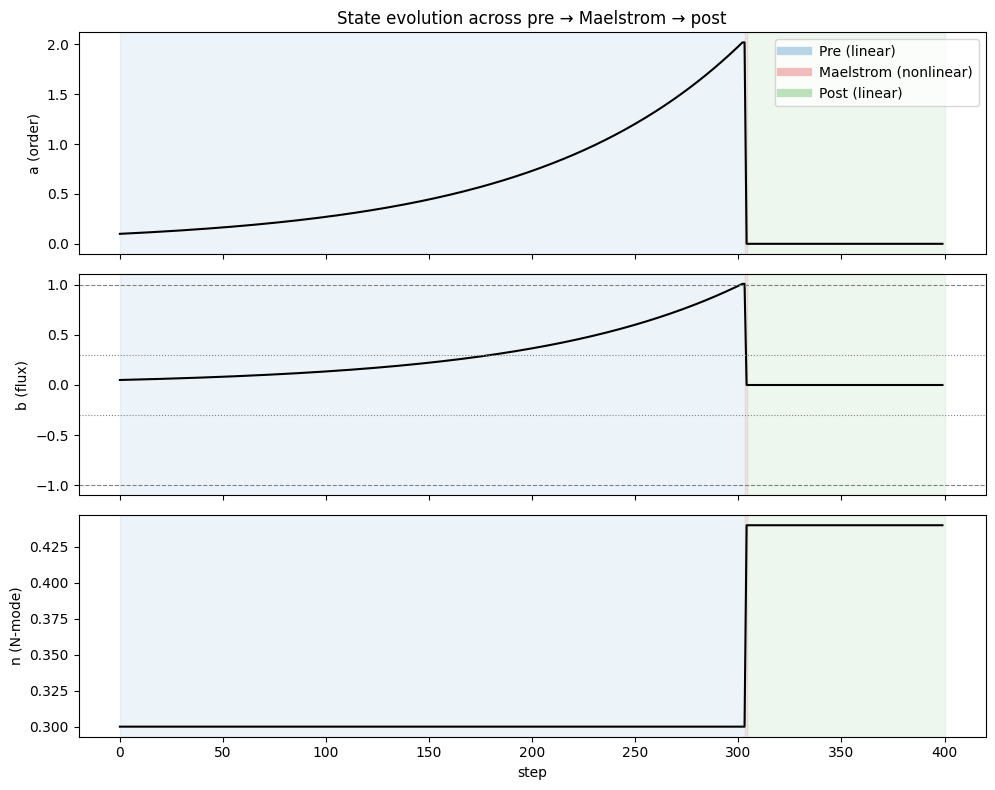

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARAMETERS
# -----------------------------

steps = 400

# Collapse / rebound thresholds on b (compensatory flux)
B_CRIT = 1.0          # enter Maelstrom when |b| >= B_CRIT
B_REBOUND = 0.3       # exit Maelstrom when |b| <= B_REBOUND

# Linear dynamics (pre- and post-)
# x_k = (a_k, b_k, n_k)
A_pre = np.array([
    [1.0,  0.02, 0.0],   # a_{k+1} depends slightly on b
    [0.0,  1.01, 0.0],   # b_{k+1} slowly grows (driving toward collapse)
    [0.0,  0.0,  1.0]    # n_{k+1} unchanged in pre-region
])
c_pre = np.array([0.0, 0.0, 0.0])

# Post-linear dynamics will depend on n (N-100 survivor) – we’ll define it as a function
def get_post_matrices(n_value):
    """
    Build A_post, c_post as a function of surviving n (N-100).
    The idea: the new ordered regime is 'tilted' by n_value.
    """
    tilt = 0.1 * np.tanh(n_value)  # bounded influence of n on the new regime

    A_post = np.array([
        [1.0 + tilt, 0.01,      0.0],
        [0.0,        1.0,       0.0],
        [0.0,        0.0,       1.0]
    ])
    c_post = np.array([0.0, 0.0, 0.0])
    return A_post, c_post

# Maelstrom (nonlinear) dynamics
def f_M(b):
    """
    Nonlinear saturation for b inside the Maelstrom.
    Logistic-like map to keep it bounded but active.
    """
    r = 2.5
    return r * b * (1 - np.clip(b, -1.0, 1.0))

def g_M(n):
    """
    N-100 survival rule.
    We treat n as tending toward a stable fixed point n* (e.g. 1.0),
    representing the invariant harmonic that survives the infinite.
    """
    n_star = 1.0
    alpha = 0.2  # relaxation rate toward n_star
    return n + alpha * (n_star - n)

# -----------------------------
# SIMULATION
# -----------------------------

# Initial state: some small a, small b, arbitrary n
x = np.array([0.1, 0.05, 0.3])  # (a_0, b_0, n_0)

# Storage
a_hist = []
b_hist = []
n_hist = []
region_hist = []  # 0 = pre, 1 = Maelstrom, 2 = post

in_maelstrom = False
in_post = False

A_post, c_post = None, None

for k in range(steps):
    a, b, n = x

    # Record
    a_hist.append(a)
    b_hist.append(b)
    n_hist.append(n)

    # Decide region
    if not in_maelstrom and not in_post:
        # Pre-collapse region
        region_hist.append(0)
        # Check for collapse trigger
        if abs(b) >= B_CRIT:
            in_maelstrom = True
        else:
            # Linear pre dynamics
            x = A_pre @ x + c_pre

    elif in_maelstrom and not in_post:
        # Maelstrom region
        region_hist.append(1)

        # Nonlinear dynamics:
        # a decoheres, b saturates nonlinearly, n survives via g_M
        a_next = 0.0
        b_next = f_M(b)
        n_next = g_M(n)
        x = np.array([a_next, b_next, n_next])

        # Check for rebound
        if abs(b_next) <= B_REBOUND:
            in_maelstrom = False
            in_post = True
            # Lock in post-linear regime based on surviving n
            A_post, c_post = get_post_matrices(n_next)

    else:
        # Post-collapse region
        region_hist.append(2)
        # Linear post dynamics (new regime shaped by surviving n)
        x = A_post @ x + c_post

# -----------------------------
# PLOTTING
# -----------------------------

t = np.arange(steps)

region_colors = {0: 'tab:blue', 1: 'tab:red', 2: 'tab:green'}
region_labels = {0: 'Pre (linear)', 1: 'Maelstrom (nonlinear)', 2: 'Post (linear)'}

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Plot a
axs[0].plot(t, a_hist, color='black')
axs[0].set_ylabel('a (order)')
axs[0].set_title('State evolution across pre → Maelstrom → post')

# Plot b
axs[1].plot(t, b_hist, color='black')
axs[1].axhline(B_CRIT, color='grey', linestyle='--', linewidth=0.8)
axs[1].axhline(-B_CRIT, color='grey', linestyle='--', linewidth=0.8)
axs[1].axhline(B_REBOUND, color='grey', linestyle=':', linewidth=0.8)
axs[1].axhline(-B_REBOUND, color='grey', linestyle=':', linewidth=0.8)
axs[1].set_ylabel('b (flux)')

# Plot n
axs[2].plot(t, n_hist, color='black')
axs[2].set_ylabel('n (N-mode)')
axs[2].set_xlabel('step')

# Shade regions
current_region = region_hist[0]
start_idx = 0
for i in range(1, steps):
    if region_hist[i] != current_region:
        for ax in axs:
            ax.axvspan(start_idx, i, color=region_colors[current_region], alpha=0.08)
        start_idx = i
        current_region = region_hist[i]
# last span
for ax in axs:
    ax.axvspan(start_idx, steps, color=region_colors[current_region], alpha=0.08)

# Legend for regions
handles = [plt.Line2D([0], [0], color=region_colors[r], lw=6, alpha=0.3)
           for r in region_colors]
labels = [region_labels[r] for r in region_colors]
axs[0].legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()
